In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

In [38]:
# Benchmark principal : 2 semiluni
X_moons, y_moons = make_moons(n_samples=600, noise=0.08, random_state=RANDOM_STATE)
X_moons = StandardScaler().fit_transform(X_moons)

# Benchmark secundar 1: cercuri concentrice
X_circles, y_circles = make_circles(n_samples=600, factor=0.5, noise=0.05, random_state=RANDOM_STATE)
X_circles = StandardScaler().fit_transform(X_circles)

# Benchmark secundar 2: blob-uri + outlieri
X_blobs, y_blobs = make_blobs(
    n_samples=500,
    centers=[(2, -2), (2, 2), (2, -2)],
    cluster_std=[0.7, 0.8, 0.6],
    random_state=RANDOM_STATE
)
X_blobs = StandardScaler().fit_transform(X_blobs)

# Adaugam outlieri artificiali
outliers = np.random.uniform(low=-4, high=4, size=(40, 2))
X_blobs_out = np.vstack([X_blobs, outliers])
y_blobs_out =np.concatenate([y_blobs, np.full(len(outliers), -1)])

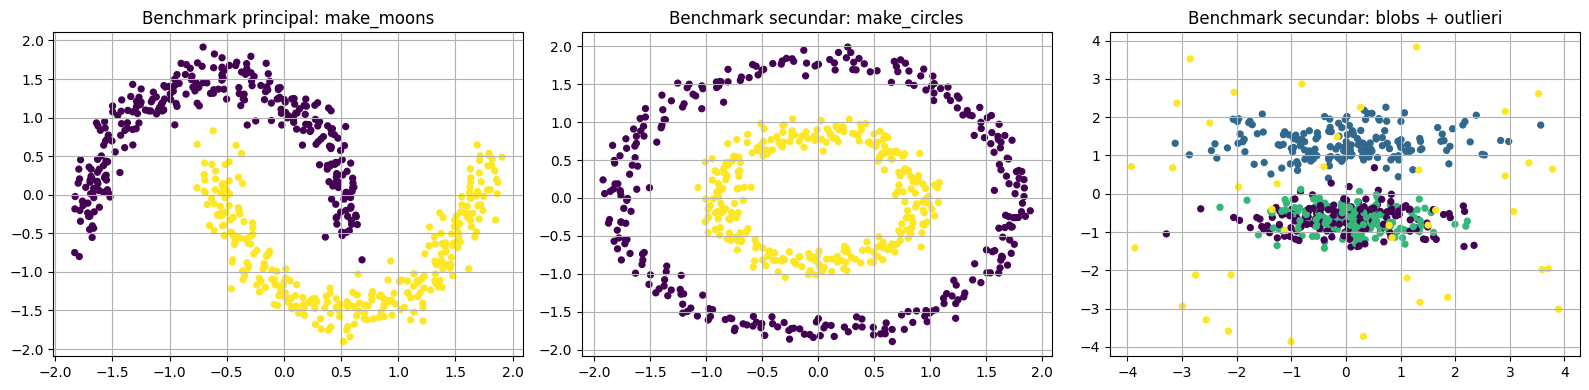

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(X_moons[:, 0 ], X_moons[:, 1], c=y_moons, s=18)
axes[0].set_title("Benchmark principal: make_moons")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, s=18)
axes[1].set_title('Benchmark secundar: make_circles')

axes[2].scatter(X_blobs_out[:, 0], X_blobs_out[:, 1], c=np.where(y_blobs_out == -1, 3, y_blobs_out), s=18)
axes[2].set_title("Benchmark secundar: blobs + outlieri")

plt.tight_layout()
plt.show()

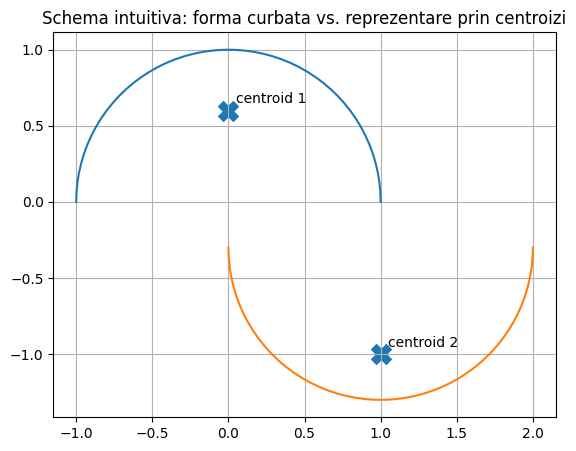

In [7]:
# Un desen intuitiv -- De ce K-Means poate rate formele neregulate?
# In schimb DBSCAN uneste regiuni dense conectate local; -ierarhic poate surprinde structura locala, mai ales cu linkage potrivit;
# -spectral proiecteaza datele intr-un spatiu unde separarea devine mai usoara
theta = np.linspace(0, np.pi, 50)
moon1_x = np.cos(theta)
moon1_y = np.sin(theta)

moon2_x = 1 - np.cos(theta)
moon2_y = -np.sin(theta) - 0.3

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(moon1_x, moon1_y)
ax.plot(moon2_x, moon2_y)

# centroizi schematici
c1 = (0.0, 0.6)
c2 = (1.0, -1.0)
ax.scatter([c1[0], c2[0]], [c1[1], c2[1]], s=200, marker='X')
ax.text(c1[0] + 0.05, c1[1] + 0.05, "centroid 1")
ax.text(c2[0] + 0.05, c2[1] + 0.05, "centroid 2")

ax.set_title("Schema intuitiva: forma curbata vs. reprezentare prin centroizi")
ax.set_aspect('equal')
plt.show()

In [8]:
def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    unique = set(labels)
    # eliminam cazul in care toate punctele sunt in acelasi cluster
    if len(unique) <= 1:
        return np.nan
    # pentru DBSCAN excludem zgomotul
    mask = labels != -1
    labels_no_noise = labels[mask]
    X_no_noise = X[mask]

    if len(X_no_noise) < 3:
        return np.nan
    if len(np.unique(labels_no_noise)) <= 1:
        return np.nan
    
    return silhouette_score(X_no_noise, labels_no_noise)

def evaluate_clustering(name, X, y_true, labels):
    ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan
    sil = safe_silhouette(X, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(np.asarray(labels) == -1)
    cluster_sizes = {int(k): int(v) for k, v in zip(*np.unique(labels, return_counts=True))}
    return {
        'algoritm': name,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'ARI': ari,
        'silhouette': sil,
        'cluster_sizes': cluster_sizes
    }

def plot_result(ax, X, labels, title):
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, s=18)
    ax.set_title(title)
    

In [9]:
# Benchmark principal: make_moons
# Fara tehnicile avansate: KMeans
kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X_moons)

res_kmeans = evaluate_clustering('KMeans', X_moons, y_moons, labels_kmeans)
res_kmeans

{'algoritm': 'KMeans',
 'n_clusters': 2,
 'noise_ratio': np.float64(0.0),
 'ARI': 0.456971471120647,
 'silhouette': 0.49232952161460863,
 'cluster_sizes': {0: 305, 1: 295}}

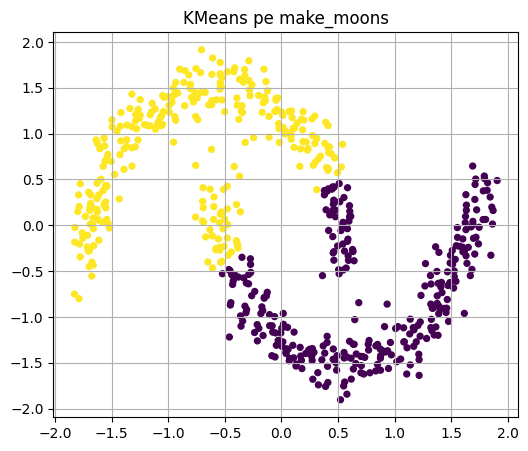

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
plot_result(ax, X_moons, labels_kmeans, 'KMeans pe make_moons')
plt.show()

DBSCAN -- cauta puncte aflate in regiuni dense; -extinde clusterlerele prin conectivitate locala; marcheaza punctele izolate drept zgomot (label = -1)

Parametri cheie: -eps - raza vecinatatii; -min_samples - cati vecini sunt necesari pentru ca un punct sa fie 'de nucleu'

In [14]:
# Pentru datele de tip 'moons', DBSCAN e o alegere excelenta
dbscan = DBSCAN(eps=0.25, min_samples=6)
labels_dbscan = dbscan.fit_predict(X_moons)

res_dbscan = evaluate_clustering('DBSCAN', X_moons, y_moons, labels_dbscan)
res_dbscan

{'algoritm': 'DBSCAN',
 'n_clusters': 2,
 'noise_ratio': np.float64(0.006666666666666667),
 'ARI': 0.9866885950585457,
 'silhouette': 0.39021465076294504,
 'cluster_sizes': {-1: 4, 0: 298, 1: 298}}

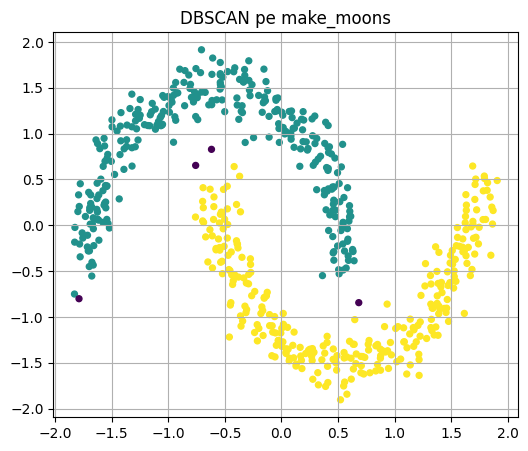

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
plot_result(ax, X_moons, labels_dbscan, 'DBSCAN pe make_moons')
plt.show()

Clustering ierarhic (AgglomerativeClustering)

- pornim de la puncte individuale si la fiecare pas unificam cele mai apropiate grupuri; rezultatul poate fi privit ca un arbore de fuziuni

- vom incerca 2 variante: (linkage='ward') --> foarte folosit, dar mai potrivit pentru grupuri compacte
                        (linkage='single') --> poate urmari mai bine conectivitatea locala, deci uneori prinde forme alungite / neregulate 

In [16]:
agg_ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_single = AgglomerativeClustering(n_clusters=2, linkage='single', metric='euclidean')

labels_agg_ward = agg_ward.fit_predict(X_moons)
labels_agg_single = agg_single.fit_predict(X_moons)

res_agg_ward = evaluate_clustering('Agglomerative (ward)', X_moons, y_moons, labels_agg_ward)
res_agg_single = evaluate_clustering('Agglomerative (single)', X_moons, y_moons, labels_agg_single)

res_agg_ward , res_agg_single

({'algoritm': 'Agglomerative (ward)',
  'n_clusters': 2,
  'noise_ratio': np.float64(0.0),
  'ARI': 0.6182343275222038,
  'silhouette': 0.45607894261921256,
  'cluster_sizes': {0: 362, 1: 238}},
 {'algoritm': 'Agglomerative (single)',
  'n_clusters': 2,
  'noise_ratio': np.float64(0.0),
  'ARI': 0.99333331487675,
  'silhouette': 0.3847004906366722,
  'cluster_sizes': {0: 301, 1: 299}})

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


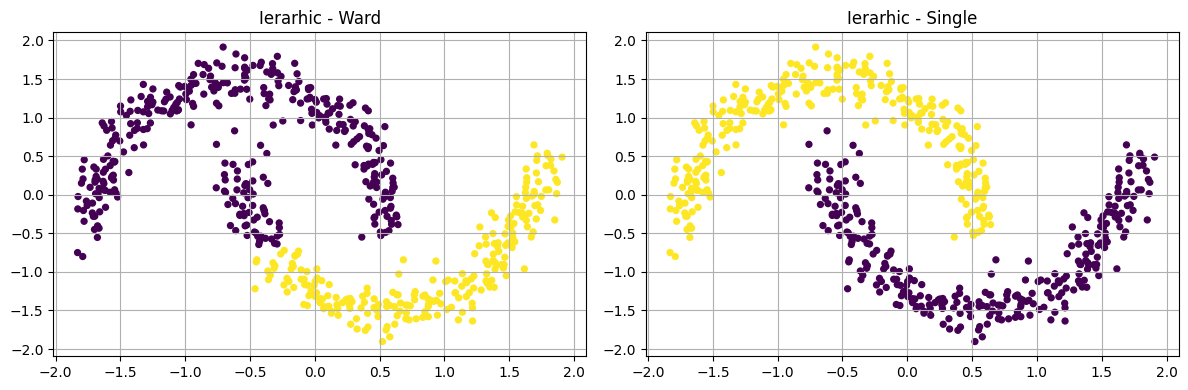

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_result(axes[0], X_moons, labels_agg_ward, "Ierarhic - Ward")
plot_result(axes[1], X_moons, labels_agg_single, "Ierarhic - Single")
plt.tight_layout()
plt.show()

Clustering Spectral

- construieste un graf de vecinatate / afinitate
- extrage o reprezentare spectrala a acestui graf
- face clustering in noul spatiu

Este foarte util atunci cand - clusterele sunt neconvexe
                             - separarea geometrica in spatiul original este dificila
                             - structura locala conteaza mai mult decat pozitia fata de un centroid

In [18]:
# Pe make_moons, spectral clustering este frecvent foarte bun
spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=12,
    assign_labels='kmeans',
    random_state=RANDOM_STATE
)
labels_spectral = spectral.fit_predict(X_moons)

res_spectral = evaluate_clustering("Spectral", X_moons, y_moons, labels_spectral)
res_spectral

{'algoritm': 'Spectral',
 'n_clusters': 2,
 'noise_ratio': np.float64(0.0),
 'ARI': 0.5922247541463067,
 'silhouette': 0.4809161168540091,
 'cluster_sizes': {0: 327, 1: 273}}

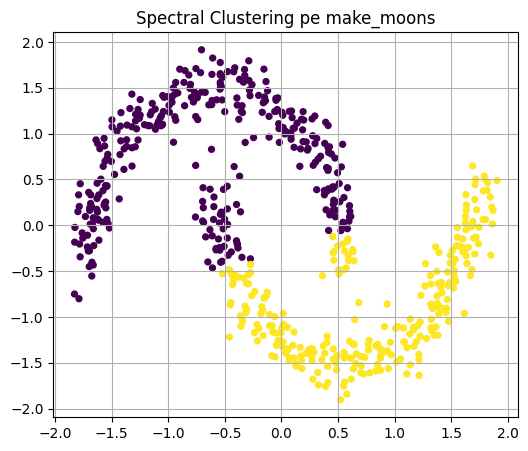

In [19]:
fig, ax = plt.subplots(figsize=(6,5))
plot_result(ax, X_moons, labels_spectral, "Spectral Clustering pe make_moons")
plt.show()

Comparatie directa pe benchmark-ul principal

comparam: -numarul de clustere gasite
          -proportia de zgomot
          - ARI
          - silhouette

OBS: un ARI mai mare sugereaza potrivire mai buna cu etichetele benchmarkului, dar un silhouette mai mare nu inseamna automat 'mai corect' cand forma clusterelor e foarte curbata

In [20]:
import pandas as pd

df_moons = pd.DataFrame([
    res_kmeans,
    res_dbscan,
    res_agg_ward,
    res_agg_single,
    res_spectral
])

df_moons[['algoritm', 'n_clusters', 'noise_ratio', 'ARI', 'silhouette']].sort_values('ARI', ascending=False)

,algoritm,n_clusters,noise_ratio,ARI,silhouette
3,Agglomerative (single),2,0.000000,0.993333,0.384700
1,DBSCAN,2,0.006667,0.986689,0.390215
2,Agglomerative (ward),2,0.000000,0.618234,0.456079
4,Spectral,2,0.000000,0.592225,0.480916
0,KMeans,2,0.000000,0.456971,0.492330


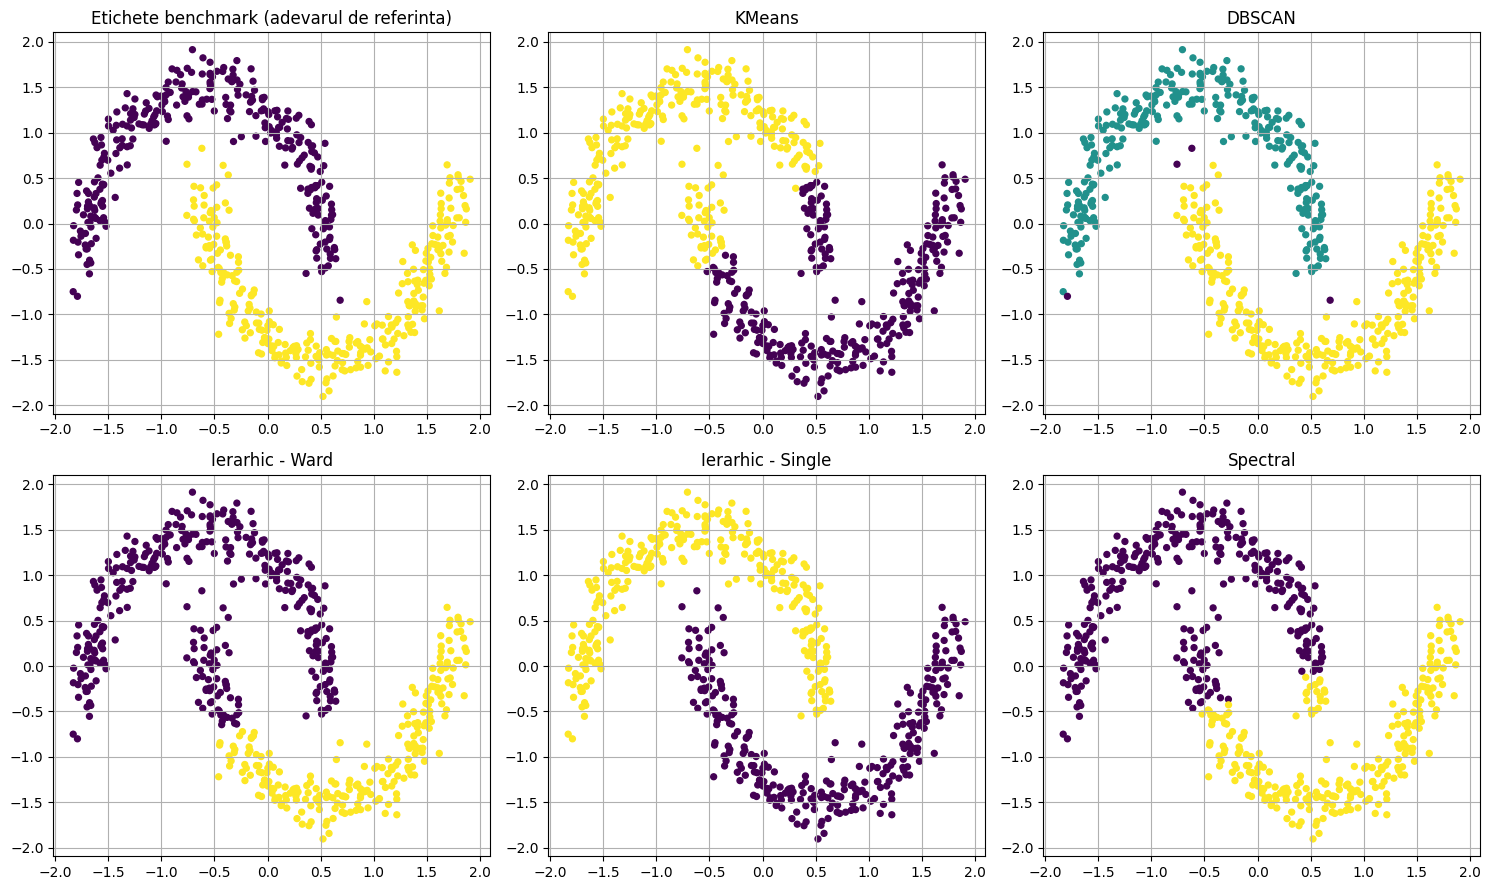

In [21]:
fig, axes = plt.subplots(2,3,figsize=(15,9))

plot_result(axes[0,0], X_moons, y_moons, 'Etichete benchmark (adevarul de referinta)')
plot_result(axes[0,1], X_moons, labels_kmeans, 'KMeans')
plot_result(axes[0,2], X_moons, labels_dbscan, 'DBSCAN')
plot_result(axes[1,0], X_moons, labels_agg_ward, 'Ierarhic - Ward')
plot_result(axes[1,1], X_moons, labels_agg_single, 'Ierarhic - Single')
plot_result(axes[1,2], X_moons, labels_spectral, 'Spectral')

plt.tight_layout()
plt.show()

Ce "se scoate" pentru interpretarea rezulatelor?

- La clustering, rezultatul nu inseamna doar 'ce eticheta a primit fiecare punct'.
- Putem extrage si interpreta mai multe lucruri utile:

1. numarul de clustere detectate
2. marimile clusterelor
3. procentul de puncte marcate ca zgomot (DBSCAN)
4. stabilitatea la schimbarea parametrilor
5. dendograma (pentru clustering ierarhic)
6. graficul distantei la al k-lea vecin (util pentru alegerea lui eps la DBSCAN)

In [24]:
# Marimile clusterelor si zgomotul
for res in [res_kmeans, res_dbscan, res_agg_ward, res_agg_single, res_spectral]:
    print(f"\n{res['algoritm']}")
    print(" numar clustere:", res['n_clusters'])
    print(" zgomot:", round(res['noise_ratio'] * 100, 2), "%")
    print(" dimensiuni:", res['cluster_sizes'])


KMeans
 numar clustere: 2
 zgomot: 0.0 %
 dimensiuni: {0: 305, 1: 295}

DBSCAN
 numar clustere: 2
 zgomot: 0.67 %
 dimensiuni: {-1: 4, 0: 298, 1: 298}

Agglomerative (ward)
 numar clustere: 2
 zgomot: 0.0 %
 dimensiuni: {0: 362, 1: 238}

Agglomerative (single)
 numar clustere: 2
 zgomot: 0.0 %
 dimensiuni: {0: 301, 1: 299}

Spectral
 numar clustere: 2
 zgomot: 0.0 %
 dimensiuni: {0: 327, 1: 273}


Dendograma pentru clustering ierarhic

- AgglomerativeClustering ofera etichete finale, dar pentru interpretare este util sa vedem si arborele de fuziuni

Mai jos construim o dendrograma cu scipy.cluster.hierarchy.linkage

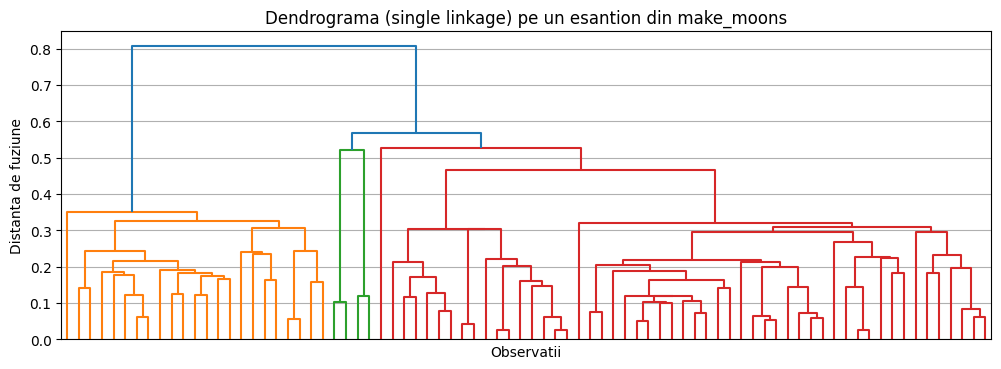

In [28]:
# Pentru claritate vizuala folosim un esantion mai mic
idx = np.random.choice(len(X_moons), size=80, replace=False)
X_small = X_moons[idx]

Z = linkage(X_small, method='single', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title('Dendrograma (single linkage) pe un esantion din make_moons')
ax.set_xlabel('Observatii')
ax.set_ylabel('Distanta de fuziune')
plt.show()

Alegerea lui eps pentru DBSCAN cu graficul k-distance

- se calculeaza distanta fiecarui punct la al k-lea vecin;
- se sorteaza aceste distante;
- se cauta un 'cot' in curba
- acel prag poate sugera o valoare buna pentru eps

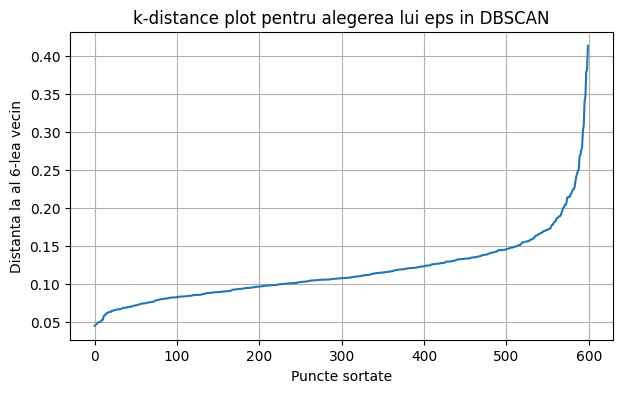

In [32]:
# Aici folosim k = min_samples
min_samples = 6
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_moons)
distances, indices = nn.kneighbors(X_moons)
k_distances = np.sort(distances[:, -1])
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(k_distances)
ax.set_title('k-distance plot pentru alegerea lui eps in DBSCAN')
ax.set_xlabel('Puncte sortate')
ax.set_ylabel(f'Distanta la al {min_samples}-lea vecin')
plt.show()

Sensibilitatea la parametri

- Mai ales la DBSCAN si spectral clustering, schimbarea parametrilor poate modifica puternic rezultatul.
- Este util sa faci un mic studiu de sensibilitate

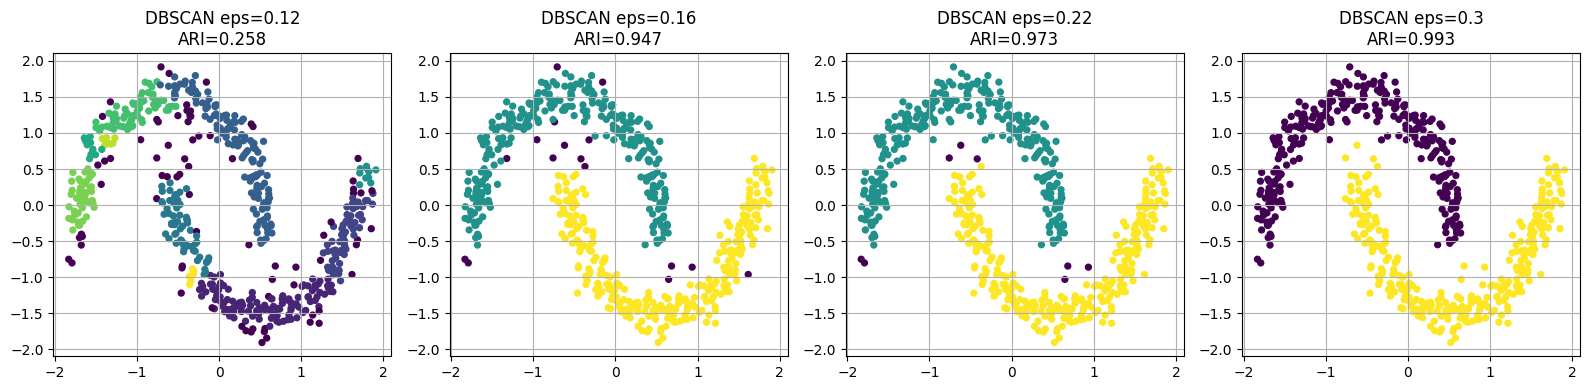

In [33]:
eps_values = [0.12, 0.16, 0.22, 0.30]

fig, axes = plt.subplots(1, len(eps_values), figsize=(16, 4))

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=6).fit_predict(X_moons)
    ari = adjusted_rand_score(y_moons, labels)
    plot_result(ax, X_moons, labels, f"DBSCAN eps={eps}\nARI={ari:.3f}")

plt.tight_layout()
plt.show()

Benchmark secudar: make_circles

Acest set este important pentru ca are doua cercuri concentrice - KMeans tinde sa 'taie' planul in zone; - spectral clustering este, de regula, foarte potrivit; - DBSCAN poate functiona bine daca densitatea este adecvata.

In [34]:
labels_km_c = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit_predict(X_circles)
labels_db_c = DBSCAN(eps=0.18, min_samples=6).fit_predict(X_circles)
labels_sp_c = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=12,
    assign_labels='kmeans',
    random_state=RANDOM_STATE
).fit_predict(X_circles)

res_circles = pd.DataFrame([
    evaluate_clustering('KMeans', X_circles, y_circles, labels_km_c),
    evaluate_clustering('DBSCAN', X_circles, y_circles, labels_db_c),
    evaluate_clustering('Spectral', X_circles, y_circles, labels_sp_c),
])

res_circles[['algoritm', 'n_clusters', 'noise_ratio', 'ARI', 'silhouette']].sort_values('ARI', ascending=False)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,algoritm,n_clusters,noise_ratio,ARI,silhouette
2,Spectral,2,0.000000,1.000000,0.114068
1,DBSCAN,8,0.006667,0.604657,0.091409
0,KMeans,2,0.000000,-0.001627,0.354529


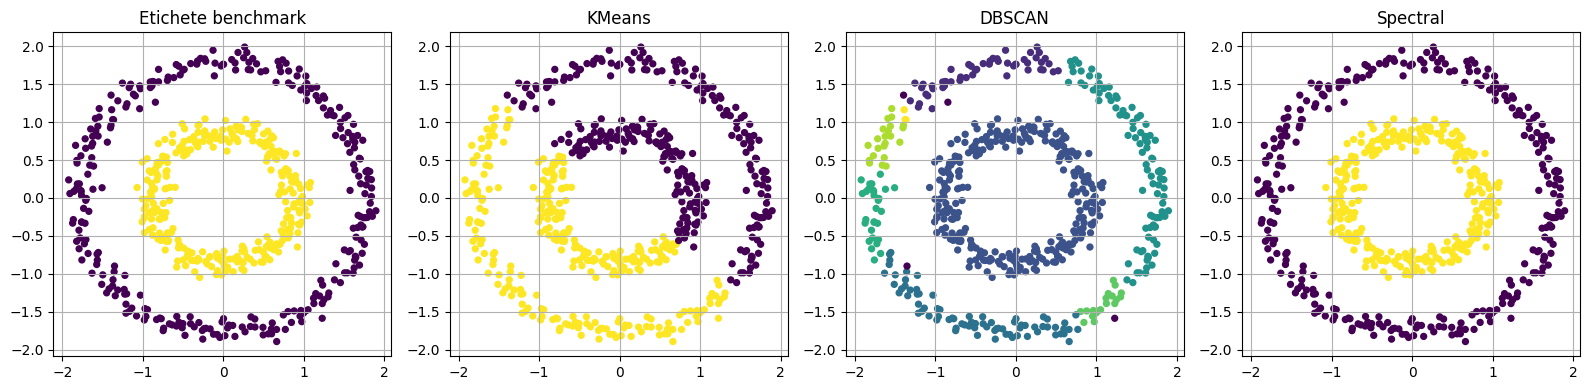

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_result(axes[0], X_circles, y_circles, 'Etichete benchmark')
plot_result(axes[1], X_circles, labels_km_c, 'KMeans')
plot_result(axes[2], X_circles, labels_db_c, 'DBSCAN')
plot_result(axes[3], X_circles, labels_sp_c, 'Spectral')

plt.tight_layout()
plt.show()

Benchmark secundar: blob-uri + outlieri

- Aici vrem sa vedem un avantaj foarte practic al lui DBSCAN: - poate identifica outlieri si ii poate eticheta cu -1; - KMeans si multe metode clasice vor forta aproape toate punctele intr-un cluster

In [40]:
# Acesta este un scenariu util cand datele reale contin observatii izolate sau zgomot
labels_km_b = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit_predict(X_blobs_out)
labels_db_b = DBSCAN(eps=0.28, min_samples=8).fit_predict(X_blobs_out)
labels_agg_b = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_blobs_out)

# Pentru ARI, excludem comparatia stricta cu eticheta -1 drept 'adevar' perfect;
# folosim totusi y_blobs_out ca referinta simplificata de benchmark

res_blobs = pd.DataFrame([
    evaluate_clustering('KMeans', X_blobs_out, y_blobs_out, labels_km_b),
    evaluate_clustering('DBSCAN', X_blobs_out, y_blobs_out, labels_db_b),
    evaluate_clustering('Agglomerative (ward)', X_blobs_out, y_blobs_out, labels_agg_b)
])

res_blobs[['algoritm', 'n_clusters', 'noise_ratio', 'ARI', 'silhouette']].sort_values('ARI', ascending=False)

,algoritm,n_clusters,noise_ratio,ARI,silhouette
1,DBSCAN,2,0.198148,0.419267,0.539929
2,Agglomerative (ward),3,0.000000,0.392083,0.435973
0,KMeans,3,0.000000,0.337790,0.396243


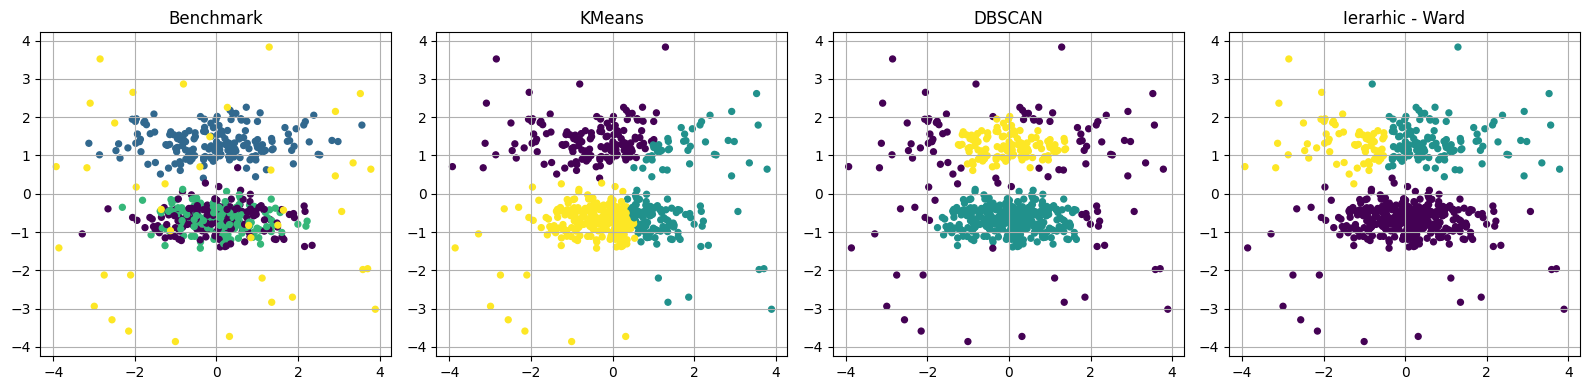

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

plot_result(axes[0], X_blobs_out, np.where(y_blobs_out == -1, 3, y_blobs_out), "Benchmark")
plot_result(axes[1], X_blobs_out, labels_km_b, "KMeans")
plot_result(axes[2], X_blobs_out, labels_db_b, "DBSCAN")
plot_result(axes[3], X_blobs_out, labels_agg_b, "Ierarhic - Ward")

plt.tight_layout()
plt.show()

-- Interpretare - Cand alegem fiecare metoda? --

DBSCAN-

- forme neregulate
- nu fixam inainte numarul de clustere
- vrem sa detectam zgomot/outlieri
Limitari: sensibil la eps si min_samples

Clustering ierarhic-

- vrem structura pe niveluri
- ne intereseaza dendrograma si interpretarea etapelor de fuziune
- avem nevoie de flexibilitate in alegerea linkage-ului
Limitari: alegerea linkage-ului conteaza mult; - pe seturi foarte mari poate deveni costisitor

Clustering spectral-

- structura este neconvexa
- relatiile de vecinatate sunt mai importante decat forma globala
- avem date unde o reprezentare pe graf are sens
Limitari: trebuie ales bine graficul de vecinatate/afinitate; poate fi mai costisitor computational decat KMeans

-- Concluzii --

Pe benchmarkul principal (make_moons), observam de regula urmatorul tipar:

- KMeans ofera un reper util, dar poate separa slab clustere curbe;
- DBSCAN surprinde bine conectivitate locala si poate recupera forme neregulate;
- Clusteringul ierarhic poate fi bun sau mediocru, in functie de linkage;
- Clusteringul spectral este adesea una dintre cele mai bune alegeri pe structuri neconvexe

-- Idee Cheie --

Nu este suficient sa spunem ca "algoritmul X a mers mai bine"
Ci merita sa aratam:

1. graficul datelor si rezultatul clusteringului;
2. o metrica externa (daca avem benchmark cu etichete);
3. o metrica interna (cu interpretare critica);
4. marimea clusterilor si, unde e cazul, zgomotul;
5. sensibilitatea la parametri